Training Model A on subset A...
Epoch 1/5 - loss: 0.3841
Epoch 2/5 - loss: 0.1348
Epoch 3/5 - loss: 0.0855
Epoch 4/5 - loss: 0.0652
Epoch 5/5 - loss: 0.0464
Training Model B on subset B...
Epoch 1/5 - loss: 0.3779
Epoch 2/5 - loss: 0.1300
Epoch 3/5 - loss: 0.0830
Epoch 4/5 - loss: 0.0619
Epoch 5/5 - loss: 0.0425
Eval Model A: 0.9711
Eval Model B: 0.9718
Naive interpolation done.
Matching layer: fc1
  applied permutation (first 10 elements): [437 216 276 404 178 407   2  39 500  25]
Matching layer: fc2
  applied permutation (first 10 elements): [245 153 495 269 276 446 430 140  86 188]
Matching layer: fc3
  applied permutation (first 10 elements): [330 348 476 264 504  32 201 335  50 292]
Eval permuted Model B: 0.9718

Training full-data model...
Epoch 1/5 - loss: 0.2672
Epoch 2/5 - loss: 0.0913
Epoch 3/5 - loss: 0.0617
Epoch 4/5 - loss: 0.0476
Epoch 5/5 - loss: 0.0364
Full-data model: 97.94%


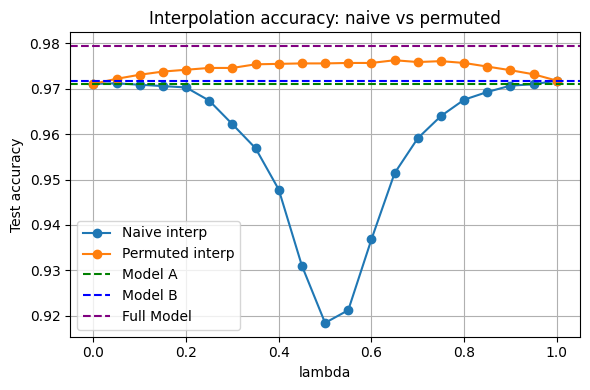

In [1]:
# Notebook: mnist_mlp_permutation_merge.ipynb (paste into a Jupyter cell)
# -----------------------------------------------------------
# Minimal MLP weight-matching + interpolation (PyTorch, MNIST)
# - Trains two MLPs on disjoint halves
# - Computes layerwise permutation via Hungarian matching
# - Applies permutation to model B
# - Plots interpolation accuracy for naive vs permuted merging
# -----------------------------------------------------------

# ---- Requirements ----
# pip install torch torchvision scipy matplotlib tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from tqdm import trange

# -------------------------
# 1) Model + data (same as you used)
# -------------------------
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 10)
        self.relu = nn.ReLU()
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return self.logsoftmax(x)

transform = transforms.ToTensor()
dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
N = len(dataset)
half = N // 2
subsetA, subsetB = random_split(dataset, [half, N - half])
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=512)

# -------------------------
# 2) Train helper (keeps on CPU)
# -------------------------
def train_model(model, dataset, epochs=5, lr=1e-3, batch_size=128, verbose=True):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.NLLLoss()
    model.train()
    for epoch in range(epochs):
        running = 0.0
        for x, y in loader:
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running += loss.item() * x.size(0)
        if verbose:
            print(f"Epoch {epoch+1}/{epochs} - loss: {running/len(loader.dataset):.4f}")
    return model

# -------------------------
# 3) Train two models (A and B)
# -------------------------
print("Training Model A on subset A...")
modelA = train_model(MLP(), subsetA, epochs=5, lr=1e-3)
print("Training Model B on subset B...")
modelB = train_model(MLP(), subsetB, epochs=5, lr=1e-3)

stateA = modelA.state_dict()
stateB = modelB.state_dict()

# -------------------------
# 4) Evaluate helper
# -------------------------
def evaluate_model_state_dict(state_dict, model_cls=MLP):
    m = model_cls()
    m.load_state_dict(state_dict)
    m.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_loader:
            out = m(x)
            pred = out.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

print("Eval Model A:", evaluate_model_state_dict(stateA))
print("Eval Model B:", evaluate_model_state_dict(stateB))

# -------------------------
# 5) Naive interpolation (for baseline)
# -------------------------
def interp_states(state1, state2, lam):
    out = {}
    for k in state1.keys():
        out[k] = (1 - lam) * state1[k].float() + lam * state2[k].float()
    return out

lambdas = np.linspace(0, 1, 21)
accs_naive = []
for lam in lambdas:
    s = interp_states(stateA, stateB, lam)
    accs_naive.append(evaluate_model_state_dict(s))
print("Naive interpolation done.")

# -------------------------
# 6) Permutation matching utilities (Hungarian per hidden layer)
# -------------------------
# Assumptions: layers named 'fc1','fc2','fc3','fc4' and we match fc1, fc2, fc3 neurons.
# For each hidden layer L (fc1/fc2/fc3) we:
#  - compute cost matrix between rows of weight_L (out_features vectors)
#    Optionally include bias and next-layer columns similarity in cost.
#  - solve assignment with Hungarian algorithm
#  - apply permutation to stateB: permute rows of weight_L and bias_L,
#    and permute columns of next layer's weight (since inputs reorder).
#
# This is a simple, robust approach used in many matching demos.

def compute_cost_matrix_rows(A_rows, B_rows, include_bias=None):
    # A_rows, B_rows: numpy arrays (n_neurons, vector_dim)
    # cost = squared L2 distance between rows
    # Optionally, include bias difference by concatenating bias value
    diff = A_rows[:, None, :] - B_rows[None, :, :]  # shape (nA, nB, dim)
    cost = np.sum(diff**2, axis=2)  # shape (nA, nB)
    return cost

def get_layer_rows_from_state(state, layer_name):
    # returns numpy array of rows for weight and bias vector concatenated if desired
    w = state[f"{layer_name}.weight"].cpu().numpy()  # shape (out, in)
    b = state.get(f"{layer_name}.bias", None)
    if b is not None:
        b = b.cpu().numpy()[:, None]  # (out,1)
        # Concatenate bias scaled so its magnitude is comparable:
        # We scale bias by mean absolute weight to keep scale sensible.
        scale = max(1.0, np.mean(np.abs(w)))
        rows = np.concatenate([w, b * scale], axis=1)
    else:
        rows = w
    return rows

def apply_permutation_to_state(state, layer_name, perm):
    """
    Applies perm (array of length out_features) to `state` IN-PLACE for:
      - permute rows of layer_name.weight
      - permute entries of layer_name.bias (if present)
      - permute columns of next layer's weight accordingly (if next exists)
    Returns modified state (new dict).
    """
    new_state = dict(state)  # shallow copy
    # permute rows of layer weight and bias
    w_key = f"{layer_name}.weight"
    b_key = f"{layer_name}.bias"
    W = state[w_key].clone().numpy()  # (out, in)
    W_perm = W[perm, :]
    new_state[w_key] = torch.from_numpy(W_perm)

    if b_key in state:
        B = state[b_key].clone().numpy()  # (out,)
        new_state[b_key] = torch.from_numpy(B[perm])

    # permute columns of next layer if it exists
    # determine next layer name in our MLP ordering:
    next_layer_map = {"fc1":"fc2", "fc2":"fc3", "fc3":"fc4"}
    if layer_name in next_layer_map:
        next_name = next_layer_map[layer_name]
        next_w_key = f"{next_name}.weight"
        W_next = state[next_w_key].clone().numpy()  # shape (out_next, in_next)
        # columns correspond to outputs of current layer; permute columns
        W_next_permcols = W_next[:, perm]
        new_state[next_w_key] = torch.from_numpy(W_next_permcols)

    return new_state

def match_layer_permutation(stateA, stateB, layer_name):
    """
    Compute permutation that matches rows of layer `layer_name` in stateB to stateA.
    Returns permutation `perm` such that row i in A ~ row perm[i] in B (i.e. perm maps A-index -> B-index).
    We'll compute permutation that maps A rows to B rows: we return array p of length n where p[i] gives index j in B.
    """
    A_rows = get_layer_rows_from_state(stateA, layer_name)
    B_rows = get_layer_rows_from_state(stateB, layer_name)
    assert A_rows.shape[0] == B_rows.shape[0], "Different neuron counts!"
    cost = compute_cost_matrix_rows(A_rows, B_rows)
    # Hungarian: minimize total cost
    row_ind, col_ind = linear_sum_assignment(cost)
    # row_ind is [0..n-1] sorted, col_ind gives assigned B-index per A-index
    # return permutation mapping A-index -> B-index
    perm = col_ind.astype(np.int64)
    return perm

# -------------------------
# 7) Compute sequential permutations for hidden layers and apply them to stateB
# -------------------------
# We'll compute permutations for fc1, then fc2, then fc3 and apply them in-place to stateB (composed).
hidden_layers = ["fc1", "fc2", "fc3"]

# Start with a copy of stateB we will permute progressively
stateB_permuted = dict(stateB)  # shallow copy

for layer in hidden_layers:
    print("Matching layer:", layer)
    perm = match_layer_permutation(stateA, stateB_permuted, layer)
    # apply permutation to stateB_permuted
    stateB_permuted = apply_permutation_to_state(stateB_permuted, layer, perm)
    print(f"  applied permutation (first 10 elements): {perm[:10]}")

# Now evaluate permuted stateB
print("Eval permuted Model B:", evaluate_model_state_dict(stateB_permuted))


# =============================================
# 8) Optional: Training full model for comparison
# =============================================
print("\nTraining full-data model...")
modelFull = train_model(MLP(), dataset, epochs=5)
modelFull_state = modelFull.state_dict()
accFull = evaluate_model_state_dict(modelFull_state)
print(f"Full-data model: {accFull*100:.2f}%")


# -------------------------
# 9) Interpolation sweep: naive vs permuted
# -------------------------
accs_naive = []
accs_permuted = []
for lam in lambdas:
    s_naive = interp_states(stateA, stateB, lam)
    s_perm  = interp_states(stateA, stateB_permuted, lam)
    accs_naive.append(evaluate_model_state_dict(s_naive))
    accs_permuted.append(evaluate_model_state_dict(s_perm))

# -------------------------
# 9) Plot results
# -------------------------
plt.figure(figsize=(6,4))
plt.plot(lambdas, accs_naive, marker='o', label='Naive interp')
plt.plot(lambdas, accs_permuted, marker='o', label='Permuted interp')
plt.axhline(evaluate_model_state_dict(stateA), color='green', linestyle='--', label='Model A')
plt.axhline(evaluate_model_state_dict(stateB), color='blue', linestyle='--', label='Model B')
plt.axhline(accFull, color = 'purple',linestyle='--', label='Full Model')
plt.title("Interpolation accuracy: naive vs permuted")
plt.xlabel("lambda")
plt.ylabel("Test accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()